In [2]:
import torch
import torch.nn as nn

In [3]:
import transformer_lens
model = transformer_lens.HookedTransformer.from_pretrained("gpt2-small")

c:\Users\matth\anaconda3\envs\tlens\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model gpt2-small into HookedTransformer


In [4]:
import transformer_lens.utils as utils


In [5]:
from transformer_lens.hook_points import (
    HookPoint,
)  # Hooking utilities


In [6]:
from transformer_lens import HookedTransformer, FactoredMatrix

In [7]:
import os
DEVELOPMENT_MODE = False

# Hot reload in development mode & not running on the CD

from IPython import get_ipython
ip = get_ipython()
if not ip.extension_manager.loaded:
    ip.extension_manager.load('autoreload')
    %autoreload 2
        
IN_GITHUB = os.getenv("GITHUB_ACTIONS") == "true"


In [8]:
# Plotly needs a different renderer for VSCode/Notebooks vs Colab argh
import plotly.io as pio

pio.renderers.default = "notebook_connected"
print(f"Using renderer: {pio.renderers.default}")

Using renderer: notebook_connected


In [9]:
# Import stuff
import pandas as pd

import einops
import circuitsvis as cv
from fancy_einsum import einsum
import tqdm.auto as tqdm
import plotly.express as px

from jaxtyping import Float
from functools import partial

In [10]:
# Ambiguous error prompt direct, zero shot prompt
prompt_zero = """Sentence: ""He hesitated to file while reviewing the materials spread across the table.""

Question:
In this sentence, what does the word ""file"" mean?

Answer:"""


In [11]:
logits_zero, cache_zero = model.run_with_cache(prompt_zero)

In [12]:
prompt_few = """Sentence: "The lawyer pulled the case file from the cabinet."
Question:
In this sentence, what does the word "file" mean?

Answer: a collection of stored information

Sentence: "She decided to file a complaint with the city office."
Question:
In this sentence, what does the word "file" mean?

Answer: to officially submit or record something

Sentence: "The mechanic ran the file along the surface to remove burrs."
Question:
In this sentence, what does the word "file" mean?

Answer: a tool used for smoothing or shaping material


Sentence: "He hesitated to file while reviewing the materials spread across the table."

Question:
In this sentence, what does the word "file" mean?

Answer:"""

logits_few, cache_few = model.run_with_cache(prompt_few)

In [13]:
tokens_zero = model.to_tokens(prompt_zero)
target_pos_zero = tokens_zero.shape[1] - 1

tokens_few = model.to_tokens(prompt_few)
target_pos_few = tokens_few.shape[1] - 1

In [14]:
candidates = [" tool", " process"]

for word in candidates:
    toks = model.to_str_tokens(word, prepend_bos=False)
    print(word, toks, len(toks))

 tool [' tool'] 1
 process [' process'] 1


In [15]:
# Testing different words for different semantic senses
correct_token = model.to_single_token(" tool")
incorrect_token = model.to_single_token(" process")

In [16]:
import torch

n_layers = model.cfg.n_layers
logit_diffs_zero = []
logit_diffs_few = []

for layer in range(n_layers):
    
    # Get residual stream at this layer
    resid_zero = cache_zero["resid_post", layer][0, target_pos_zero]
    resid_few = cache_few["resid_post", layer][0, target_pos_few]
    
    # Project to logits (logit lens)
    logits_layer_zero = model.unembed(resid_zero)
    logits_layer_few = model.unembed(resid_few)
    
    # Compute logit difference
    diff_zero = logits_layer_zero[correct_token] - logits_layer_zero[incorrect_token]
    diff_few = logits_layer_few[correct_token] - logits_layer_few[incorrect_token]
    
    logit_diffs_zero.append(diff_zero.item())
    logit_diffs_few.append(diff_few.item())

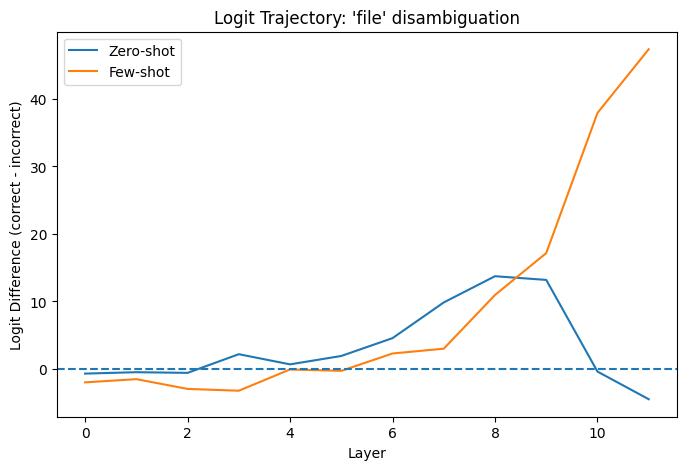

: 

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(logit_diffs_zero, label="Zero-shot")
plt.plot(logit_diffs_few, label="Few-shot")
plt.axhline(0, linestyle="--")

plt.xlabel("Layer")
plt.ylabel("Logit Difference (correct - incorrect)")
plt.title("Logit Trajectory: 'file' disambiguation")
plt.legend()
plt.show()

In [18]:
logit_df = pd.DataFrame({'few': logit_diffs_few, 'zero': logit_diffs_zero})
logit_df

,few,zero
0,-1.987585,-0.690381
1,-1.513430,-0.481660
2,-2.958514,-0.583833
3,-3.225951,2.184253
4,-0.075938,0.677938
5,-0.283867,1.920683
6,2.288803,4.564041
7,3.001273,9.852988
8,10.954470,13.736303
9,17.164452,13.189373


In [19]:
tokens = model.to_tokens(prompt_zero)
str_tokens = model.to_str_tokens(tokens)

for i, tok in enumerate(str_tokens):
    print(i, tok)

0 <|endoftext|>
1 Sent
2 ence
3 :
4  ""
5 He
6  hesitated
7  to
8  file
9  while
10  reviewing
11  the
12  materials
13  spread
14  across
15  the
16  table
17 .""
18 

19 

20 Question
21 :
22 

23 In
24  this
25  sentence
26 ,
27  what
28  does
29  the
30  word
31  ""
32 file
33 ""
34  mean
35 ?
36 

37 

38 Answer
39 :


In [19]:
pitch_zero_pos = 8

In [20]:
tokens = model.to_tokens(prompt_few)
str_tokens = model.to_str_tokens(tokens)

for i, tok in enumerate(str_tokens):
    print(i, tok)

0 <|endoftext|>
1 Sent
2 ence
3 :
4  "
5 She
6  stepped
7  forward
8  to
9  pitch
10  the
11  stone
12  into
13  the
14  lake
15 ."
16 

17 Question
18 :
19 

20 In
21  this
22  sentence
23 ,
24  what
25  does
26  the
27  word
28  "
29 p
30 itch
31 "
32  mean
33 ?
34 

35 

36 Answer
37 :
38  to
39  throw
40  something
41 

42 

43 Sent
44 ence
45 :
46  "
47 He
48  had
49  to
50  pitch
51  the
52  package
53  over
54  the
55  fence
56 ."
57 

58 Question
59 :
60 

61 In
62  this
63  sentence
64 ,
65  what
66  does
67  the
68  word
69  "
70 p
71 itch
72 "
73  mean
74 ?
75 

76 

77 Answer
78 :
79  to
80  throw
81  something
82 

83 

84 Sent
85 ence
86 :
87  "
88 He
89  struggled
90  to
91  match
92  the
93  pitch
94  of
95  the
96  note
97 ."
98 

99 Question
100 :
101 

102 In
103  this
104  sentence
105 ,
106  what
107  does
108  the
109  word
110  "
111 p
112 itch
113 "
114  mean
115 ?
116 

117 

118 Answer
119 :
120  the
121  perceived
122  high
123 ness
124  or
125  l
126 own
127